In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python environment is ready.")

Python environment is ready.


In [2]:
project_root = Path.cwd()

if not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root / "src"))

from ta_chirp.io import read_ta_csv

print("Project root:", project_root)

Project root: c:\Users\zheng\Desktop\Githubproject\TA-chirp-correction


In [3]:
sample_path = project_root / "data" / "example" / "sample_example.csv"
solvent_path = project_root / "data" / "example" / "solvent_example.csv"

sample_wavelength, sample_delay, sample_signal = read_ta_csv(sample_path)
solvent_wavelength, solvent_delay, solvent_signal = read_ta_csv(solvent_path)

print("Sample:")
print("  wavelength shape:", sample_wavelength.shape)
print("  delay shape:", sample_delay.shape)
print("  signal shape:", sample_signal.shape)
print("  wavelength range:",
      sample_wavelength.min(), sample_wavelength.max())
print("  delay range:",
      sample_delay.min(), sample_delay.max())

print("\nSolvent:")
print("  wavelength shape:", solvent_wavelength.shape)
print("  delay shape:", solvent_delay.shape)
print("  signal shape:", solvent_signal.shape)
print("  wavelength range:",
      solvent_wavelength.min(), solvent_wavelength.max())
print("  delay range:",
      solvent_delay.min(), solvent_delay.max())

Sample:
  wavelength shape: (489,)
  delay shape: (337,)
  signal shape: (489, 337)
  wavelength range: 449.7644653 750.3455811
  delay range: -2.707672119 7549.501479499999

Solvent:
  wavelength shape: (489,)
  delay shape: (101,)
  signal shape: (489, 101)
  wavelength range: 449.7644653 750.3455811
  delay range: -7.001139323 2.998860677


In [4]:
assert sample_signal.shape == (
    len(sample_wavelength), len(sample_delay)
)

assert solvent_signal.shape == (
    len(solvent_wavelength), len(solvent_delay)
)

assert np.allclose(sample_wavelength, solvent_wavelength)

assert np.all(np.isfinite(sample_signal))
assert np.all(np.isfinite(solvent_signal))

print("Input validation passed.")

Input validation passed.


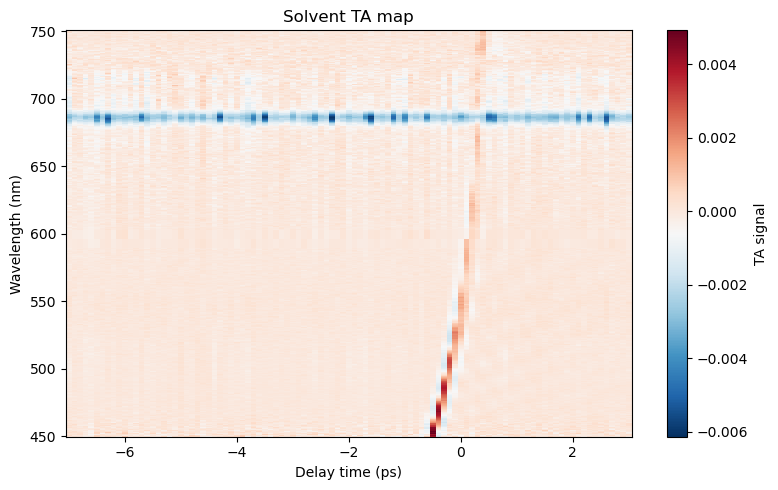

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

mesh = ax.pcolormesh(
    solvent_delay,
    solvent_wavelength,
    solvent_signal,
    shading="auto",
    cmap="RdBu_r"
)

ax.set_xlabel("Delay time (ps)")
ax.set_ylabel("Wavelength (nm)")
ax.set_title("Solvent TA map")

fig.colorbar(mesh, ax=ax, label="TA signal")

plt.tight_layout()
plt.show()